<a href="https://colab.research.google.com/github/RAK789266/http-localhost-8888-notebooks-Untitled13.ipynb-kernel_name-python3/blob/main/Stock_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import datetime as datetiime

import warnings
warnings.filterwarnings('ignore')

In [24]:
# Load the dataset

def load_data():
  data =  pd.read_csv(r'/content/all_stocks_5yrs.csv', encoding = 'utf-8', delimiter=',', on_bad_lines='skip')
  return df

In [25]:
print(load_data)

<function load_data at 0x7f754713afc0>


In [26]:
data = load_data()
data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [27]:
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 33.1+ MB


Exploratory Data Analysis (EDA)

Let visualize the data of major companies such as Google ,apple , facebook for 5 years


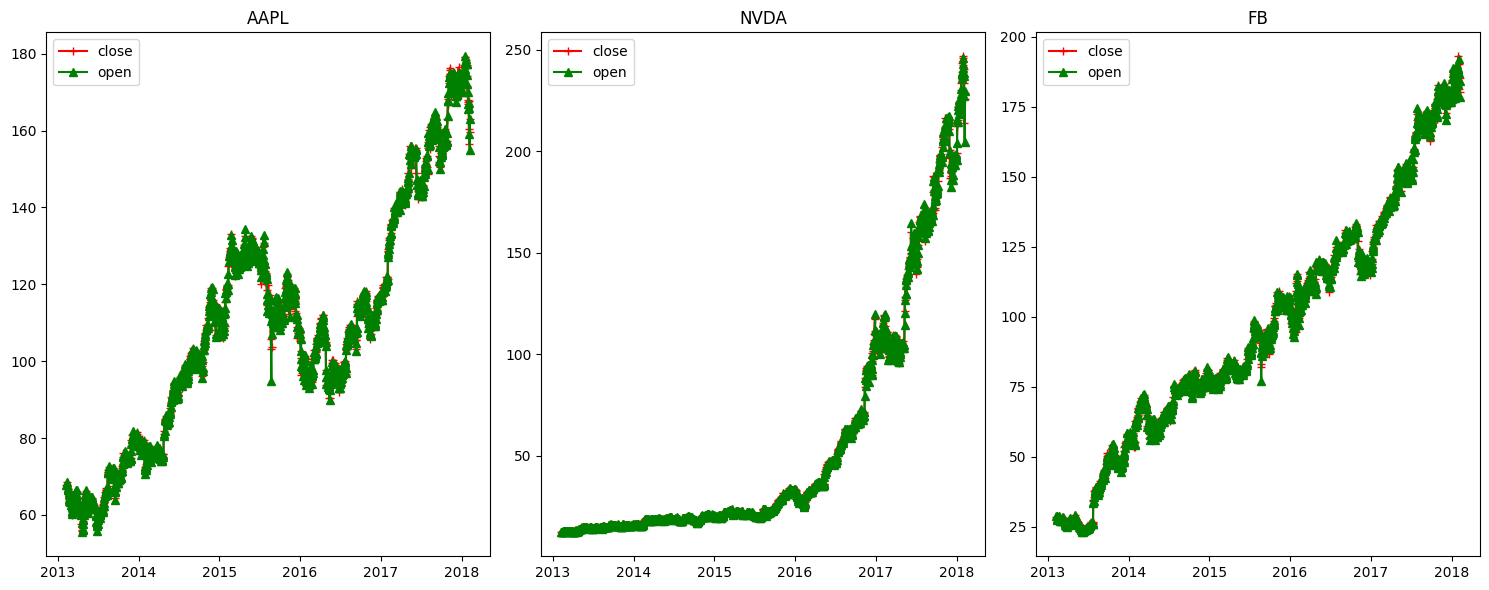

In [28]:
companies = ['AAPL', 'NVDA', 'FB']

plt.figure(figsize=(15,6))
for index, company in enumerate(companies):
  plt.subplot(1,3,index+1)
  c = data[data['Name']==company]
  plt.plot(c['date'], c['close'], color='red', label='close', marker='+')
  plt.plot(c['date'], c['open'], color='green', label='open', marker='^')
  plt.title(company)
  plt.legend()
  plt.tight_layout()

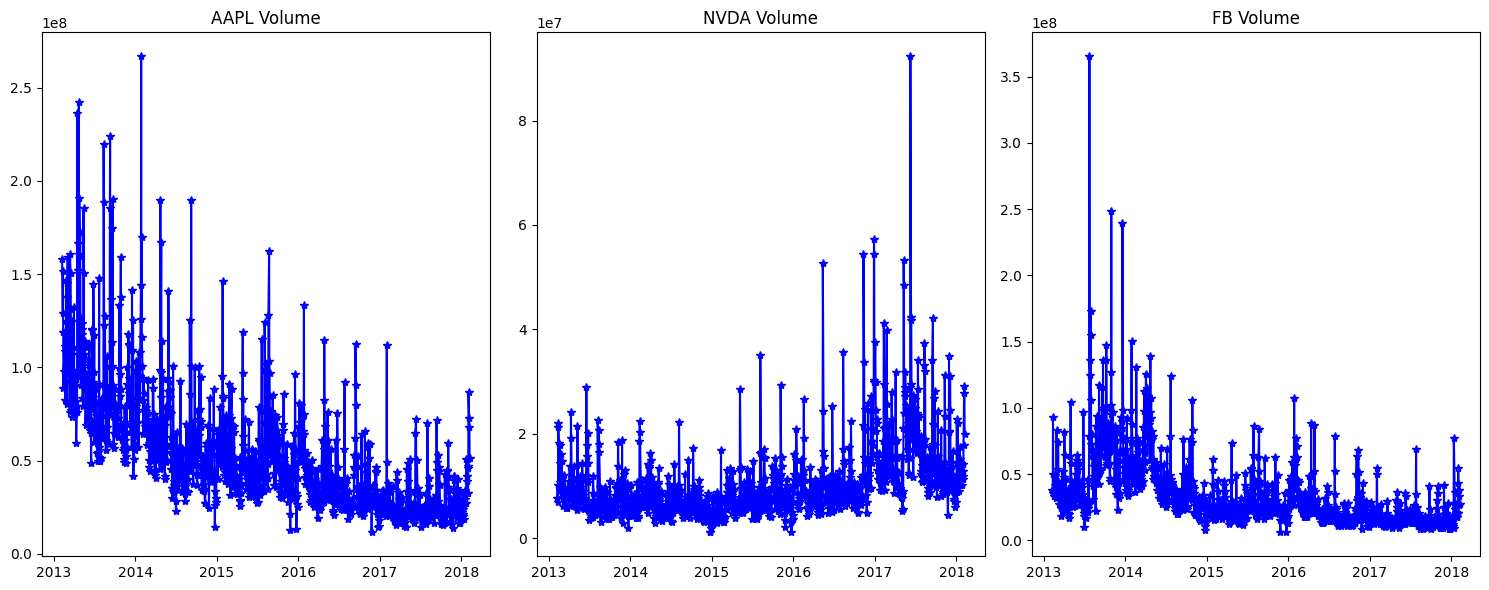

In [29]:
plt.figure(figsize=(15,6))

for index, company in enumerate(companies):
  plt.subplot(1,3,index+1)
  c=data[data['Name']==company]
  plt.plot(c['date'], c['volume'], color='blue', label='volume', marker='*')
  plt.title(f"{company} Volume")
  plt.tight_layout()



In [30]:
# let analyze the data for NVIDIA stock


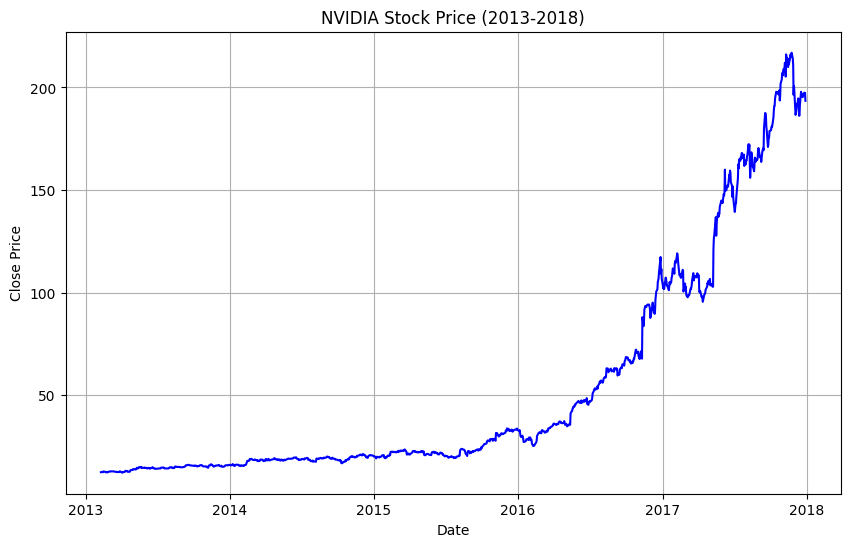

In [31]:
nvda = data[data['Name'] == 'NVDA']


pred_range = nvda.loc[(nvda['date'] > pd.to_datetime('2013-01-01'))
& (nvda['date'] < pd.to_datetime('2018-01-01'))]

plt.figure(figsize=(10, 6))
plt.plot(pred_range['date'], pred_range['close'], color='blue')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("NVIDIA Stock Price (2013-2018)")
plt.grid(True)
plt.show()

In [32]:
# subset  whole data as training set to left with a subset of data for the validation part

close_data = nvda.filter(['close'])
dataset = close_data.values
training = int(np.ceil(len(dataset) * .95))

print(training)

1197


In [33]:

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

train_data = scaled_data[0:int(training),:]

# Prepare feature and label
x_train=[]
y_train=[]

for i in range (60, len(train_data)):
  x_train.append(train_data[i-60:i,0])
  y_train.append(train_data[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)


 we will create LSTM models. it is used in Recurrent neural networks for sequence models and time series data. It is used to avoid the vanishing gradient issue which is widely occured in training RNN.

In [36]:
model = keras.models.Sequential()
model.add(keras.layers.LSTM(units=64,
                            return_sequences=True,
                            input_shape=(x_train.shape[1], 1)))
model.add(keras.layers.LSTM(units=64))
model.add(keras.layers.Dense(32))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1))
model.summary

<bound method Model.summary of <Sequential name=sequential_1, built=True>>

In [37]:
model.compile(optimizer='adam',
              loss='mean_squared_error')
history = model.fit(x_train,
                    y_train,
                    epochs=10)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.0123
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0029
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0026
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0026
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0030
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0022
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0025
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0022
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0020
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0026


In [40]:
test_data = scaled_data[training - 60:, :]
x_test = []
y_test = dataset[training:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

mse = np.mean(((predictions - y_test) ** 2))
rmse = np.sqrt(mse)

print("MSE", mse)
print("RMSE", np.sqrt(mse))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
MSE 204.48009126614164
RMSE 14.29965353657709


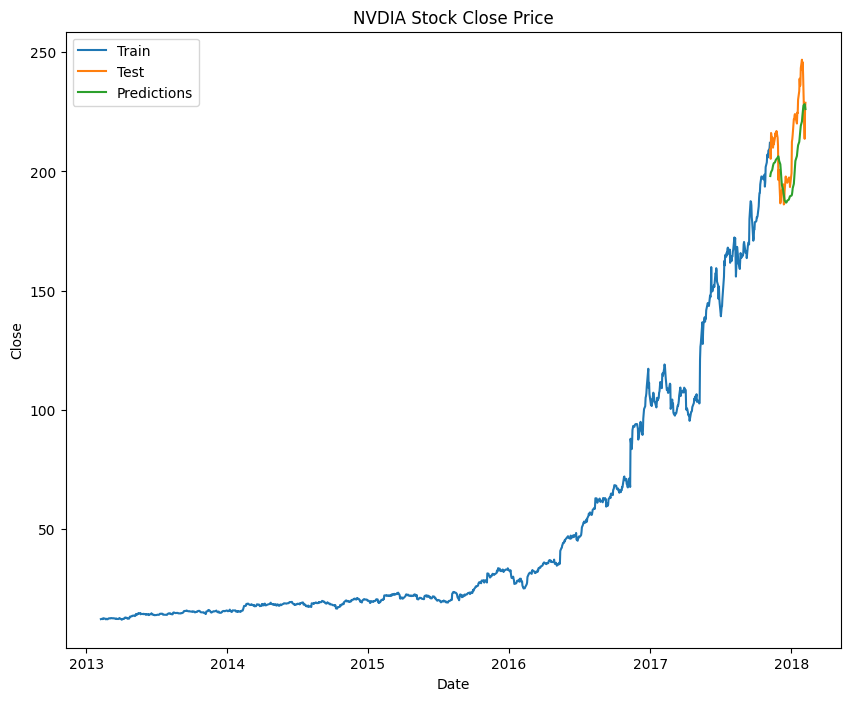

In [43]:
train = nvda[:training]
test = nvda[training:]
test['Predictions'] = predictions

plt.figure(figsize=(10, 8))
plt.plot(train['date'], train['close'])
plt.plot(test['date'], test[['close', 'Predictions']])
plt.title('NVDIA Stock Close Price')
plt.xlabel('Date')
plt.ylabel("Close")
plt.legend(['Train', 'Test', 'Predictions'])